# 2D Likelihood Contours: CW Sky Position vs Pulsar Distance

Companion to ``likelihood_contour_frequency_vs_distance.ipynb``. Here we
build the same synthetic PTA and inject the same single CW source, then
sweep two 2D grids:

1. **CW right ascension** (``gwphi``, rad) vs target pulsar distance.
2. **CW declination** (degrees, derived from ``cos_gwtheta``) vs target pulsar distance.

Internally the source position uses ``gwphi`` and ``cos_gwtheta`` (cosine of
the GW source colatitude). We convert to/from declination via
``cos_gwtheta = sin(DEC)``. ``PX`` is parallax in mas (PINT / ``types.py``
convention); the y-axis is shown in kpc via ``d = 1 / PX_mas`` and
``CWInjector`` applies the same conversion when computing the Ellis+2012
pulsar-term phase.

In [19]:
%matplotlib widget
import matplotlib.pyplot as plt

In [20]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import pint.models as pm

from jaxpint.pta.likelihood import pta_logL
from jaxpint.notebook_utils import (
    build_cw_injectors,
    generate_random_par,
    inject_and_build_config,
    plot_2d_delta_logL,
    setup_synthetic_pta,
    sweep_2d_logL,
)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 1
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 64300.0       
TOA_ERROR = 1e-8         
FREQ = 1400.0            # MHz
SEED = 42
GRID_DENSITY = 2000

## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, and
distance. The par file includes spindown (F0, F1), astrometry (RAJ, DECJ, PX),
and unscaled white noise (EFAC = 1).

In [21]:
rng = np.random.default_rng(SEED)

par_strings = [generate_random_par(idx, rng, start_mjd=START_MJD) for idx in range(N_PULSARS)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")

Generated 10 pulsars
Example .par:
PSR           J1834-0701_00
RAJ           18:34:29.80260
DECJ          -07:01:17.6778
F0            443.4391679646
F1            -2.481624e-15
PEPOCH        57000.0
PX            1.359724
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0



## Generate fake TOAs and convert to JaxPINT

In [22]:
synthetic = setup_synthetic_pta(
    pint_models,
    start_mjd=START_MJD, end_mjd=END_MJD,
    n_toas=N_TOAS, toa_error_s=TOA_ERROR, freq_mhz=FREQ,
)
pp_tuple = synthetic.pulsar_params_list

for i, model in enumerate(pint_models):
    px_mas = float(pp_tuple[i].param_value("PX"))
    distance_kpc = 1.0 / px_mas
    f0 = float(pp_tuple[i].param_value("F0"))
    print(
        f"  Pulsar {i}: {model.PSR.value:>20s}  "
        f"PX={px_mas:.3f} mas (d={distance_kpc:.2f} kpc)  F0={f0:.1f} Hz"
    )

print(f"\nAll {N_PULSARS} pulsars loaded.")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 59 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'gps2utc.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'time_gbt.dat'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}

  Pulsar 0:        J1834-0701_00  PX=1.360 mas (d=0.74 kpc)  F0=443.4 Hz
  Pulsar 1:        J2324+3129_01  PX=0.615 mas (d=1.63 kpc)  F0=414.4 Hz
  Pulsar 2:        J0853+5835_02  PX=0.622 mas (d=1.61 kpc)  F0=357.5 Hz
  Pulsar 3:        J0527+0616_03  PX=0.481 mas (d=2.08 kpc)  F0=125.5 Hz
  Pulsar 4:        J1811-1654_04  PX=0.409 mas (d=2.45 kpc)  F0=488.3 Hz
  Pulsar 5:        J0440-0348_05  PX=0.453 mas (d=2.21 kpc)  F0=117.5 Hz
  Pulsar 6:        J1752+6913_06  PX=0.597 mas (d=1.67 kpc)  F0=230.3 Hz
  Pulsar 7:        J0432-4744_07  PX=0.460 mas (d=2.17 kpc)  F0=290.3 Hz
  Pulsar 8:        J1029+4142_08  PX=0.387 mas (d=2.58 kpc)  F0=380.1 Hz
  Pulsar 9:        J1918-1300_09  PX=1.177 mas (d=0.85 kpc)  F0=215.3 Hz

All 10 pulsars loaded.


## Set up M CW sources and inject into TOAs

We place M continuous gravitational wave sources at random sky locations with
random nHz-band GW frequencies and strain amplitude $h = 10^{-14}$.

In [23]:
cw_injectors, _ = build_cw_injectors(
    pint_models, n_sources=M_CW_SOURCES, rng=rng, log10_h=-14.0,
)

for m, inj in enumerate(cw_injectors):
    print(
        f"  CW source {m}: cos_gwtheta={inj.param_spec['cos_gwtheta']:.3f}, "
        f"gwphi={inj.param_spec['gwphi']:.3f}, "
        f"log10_fgw={inj.param_spec['log10_fgw']:.2f}"
    )

gp, config = inject_and_build_config(synthetic, cw_injectors)

TRUE_GWPHI = float(cw_injectors[0].param_spec["gwphi"])
TRUE_COS_GWTHETA = float(cw_injectors[0].param_spec["cos_gwtheta"])
TRUE_DEC_RAD = float(np.arcsin(TRUE_COS_GWTHETA))
TRUE_DEC_DEG = float(np.degrees(TRUE_DEC_RAD))

print(f"\nPTA config built with {M_CW_SOURCES} CW sources.")
print(f"Global params: {gp.names}")
print(
    f"True CW source 0: gwphi(RA) = {TRUE_GWPHI:.4f} rad "
    f"({np.degrees(TRUE_GWPHI):.3f} deg), DEC = {TRUE_DEC_DEG:.3f} deg "
    f"(cos_gwtheta = {TRUE_COS_GWTHETA:.4f})"
)

  CW source 0: cos_gwtheta=-0.600, gwphi=0.046, log10_fgw=-7.43

PTA config built with 1 CW sources.
Global params: ('cw0_log10_h', 'cw0_cos_gwtheta', 'cw0_gwphi', 'cw0_log10_fgw', 'cw0_cos_inc', 'cw0_psi', 'cw0_phase0')
True CW source 0: gwphi(RA) = 0.0463 rad (2.650 deg), DEC = -36.883 deg (cos_gwtheta = -0.6002)


## 2D sweep: CW right ascension vs pulsar distance

Sweep the GW source RA of CW source 0 (``cw0_gwphi``) and the distance of
pulsar 0 (``PX``) over a 2D grid. The angular window is intentionally narrow
(~1 mrad on each side of truth) so the pulsar-term fringe pattern is
resolved on a 5000×5000 grid.

In [24]:
TARGET_PULSAR = 0
true_px_mas = float(pp_tuple[TARGET_PULSAR].param_value("PX"))
true_distance = 1.0 / true_px_mas  # kpc
print(f"Pulsar {TARGET_PULSAR} true distance: {true_distance:.3f} kpc "
      f"(PX = {true_px_mas:.4f} mas)")
print(f"True gwphi (RA) for CW source 0: {TRUE_GWPHI:.6f} rad")

half_window_px = 0.005           # kpc (y-axis window in distance)
half_window_gwphi = 1e-2         # radians

gwphi_grid = np.linspace(
    TRUE_GWPHI - half_window_gwphi,
    TRUE_GWPHI + half_window_gwphi,
    GRID_DENSITY
)
# Distance grid in kpc for the plot axis; invert to mas for the sweep so
# the likelihood receives physically correct parallax values.
distance_grid = np.linspace(
    true_distance - half_window_px,
    true_distance + half_window_px,
    GRID_DENSITY
)
px_mas_grid = 1.0 / distance_grid

def eval_logL_ra(gwphi_val, px_mas_val):
    gp_mod = gp.with_value("cw0_gwphi", gwphi_val)
    pp_mod_0 = pp_tuple[TARGET_PULSAR].with_value("PX", px_mas_val)
    pp_mod = pp_tuple[:TARGET_PULSAR] + (pp_mod_0,) + pp_tuple[TARGET_PULSAR + 1:]
    return pta_logL(gp_mod, pp_mod, config)

print(f"Computing {len(gwphi_grid)} x {len(px_mas_grid)} = "
      f"{len(gwphi_grid) * len(px_mas_grid)} likelihood evaluations...")
logL_ra = sweep_2d_logL(eval_logL_ra, gwphi_grid, px_mas_grid)
print("Done.")

Pulsar 0 true distance: 0.735 kpc (PX = 1.3597 mas)
True gwphi (RA) for CW source 0: 0.046259 rad
Computing 2000 x 2000 = 4000000 likelihood evaluations...
Done.


### Colormesh plot — RA vs distance

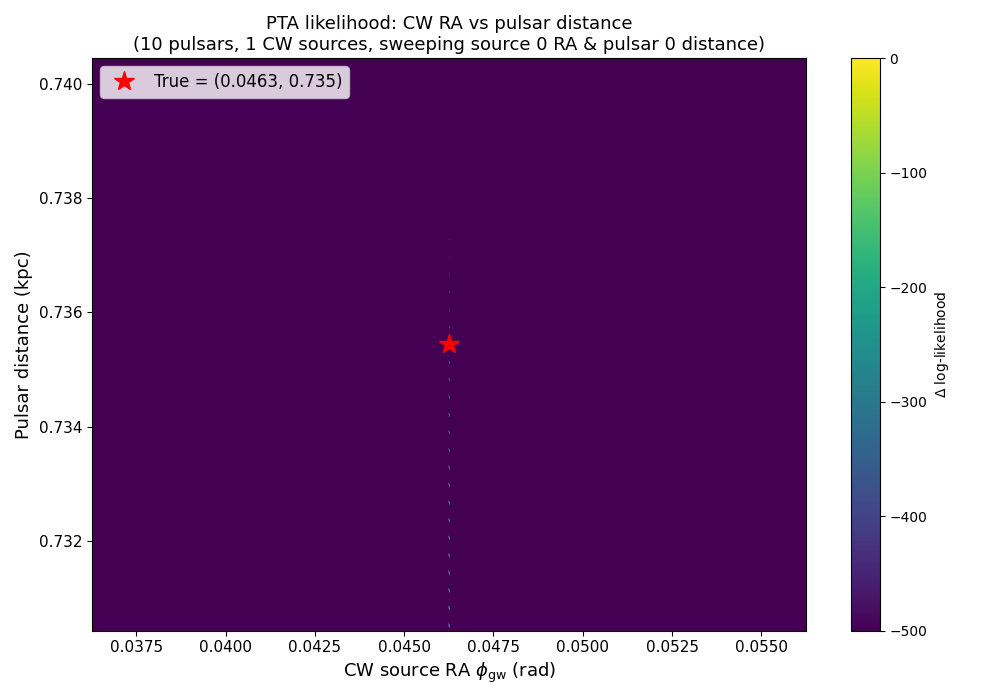

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))

# logL_ra row order follows px_mas_grid (descending in kpc); flip for plotting.
distance_grid_plot = distance_grid[::-1]
logL_ra_plot = logL_ra[::-1, :]

mesh = plot_2d_delta_logL(
    ax, gwphi_grid, distance_grid_plot, logL_ra_plot,
    true_xy=(TRUE_GWPHI, true_distance),
)
ax.set_xlabel(r"CW source RA $\phi_{\rm gw}$ (rad)", fontsize=13)
ax.set_ylabel("Pulsar distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA likelihood: CW RA vs pulsar distance\n"
    f"({N_PULSARS} pulsars, {M_CW_SOURCES} CW sources, "
    f"sweeping source 0 RA & pulsar {TARGET_PULSAR} distance)",
    fontsize=13,
)
ax.legend(fontsize=12, loc="upper left")
ax.tick_params(labelsize=11)
fig.colorbar(mesh, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()

## 2D sweep: CW declination vs pulsar distance

Sweep the GW source declination of CW source 0 vs pulsar 0 distance. The
underlying parameter is ``cw0_cos_gwtheta``; we generate a grid in DEC
(degrees) for the plot axis and convert via ``cos_gwtheta = sin(DEC)``
before evaluating the likelihood. The angular half-window is again ~1 mrad
(≈0.057°).

In [26]:
print(f"True DEC for CW source 0: {TRUE_DEC_DEG:.4f} deg "
      f"(cos_gwtheta = {TRUE_COS_GWTHETA:.4f})")

half_window_dec_rad = 1e-2                                # radians
half_window_dec_deg = float(np.degrees(half_window_dec_rad))

dec_deg_grid = np.linspace(
    TRUE_DEC_DEG - half_window_dec_deg,
    TRUE_DEC_DEG + half_window_dec_deg,
    GRID_DENSITY
)
cos_gwtheta_grid = np.sin(np.radians(dec_deg_grid))

# Reuse the same distance grid as the RA sweep.
def eval_logL_dec(cos_gwtheta_val, px_mas_val):
    gp_mod = gp.with_value("cw0_cos_gwtheta", cos_gwtheta_val)
    pp_mod_0 = pp_tuple[TARGET_PULSAR].with_value("PX", px_mas_val)
    pp_mod = pp_tuple[:TARGET_PULSAR] + (pp_mod_0,) + pp_tuple[TARGET_PULSAR + 1:]
    return pta_logL(gp_mod, pp_mod, config)

print(f"Computing {len(cos_gwtheta_grid)} x {len(px_mas_grid)} = "
      f"{len(cos_gwtheta_grid) * len(px_mas_grid)} likelihood evaluations...")
logL_dec = sweep_2d_logL(eval_logL_dec, cos_gwtheta_grid, px_mas_grid)
print("Done.")

True DEC for CW source 0: -36.8830 deg (cos_gwtheta = -0.6002)
Computing 2000 x 2000 = 4000000 likelihood evaluations...
Done.


### Colormesh plot — DEC vs distance

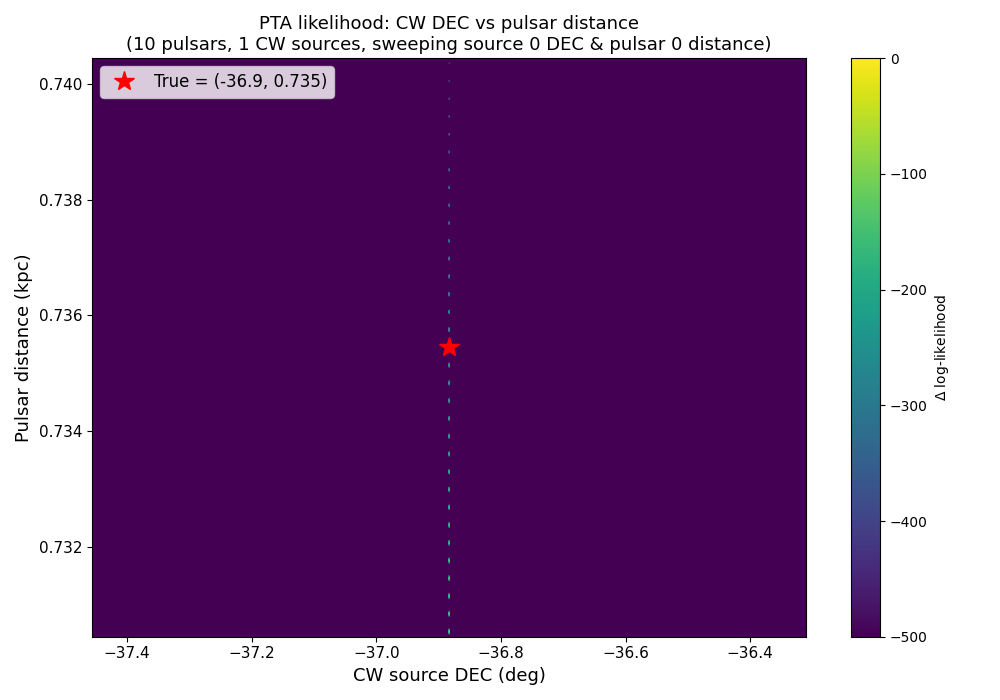

In [27]:
fig, ax = plt.subplots(figsize=(10, 7))

distance_grid_plot = distance_grid[::-1]
logL_dec_plot = logL_dec[::-1, :]

mesh = plot_2d_delta_logL(
    ax, dec_deg_grid, distance_grid_plot, logL_dec_plot,
    true_xy=(TRUE_DEC_DEG, true_distance),
)
ax.set_xlabel(r"CW source DEC (deg)", fontsize=13)
ax.set_ylabel("Pulsar distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA likelihood: CW DEC vs pulsar distance\n"
    f"({N_PULSARS} pulsars, {M_CW_SOURCES} CW sources, "
    f"sweeping source 0 DEC & pulsar {TARGET_PULSAR} distance)",
    fontsize=13,
)
ax.legend(fontsize=12, loc="upper left")
ax.tick_params(labelsize=11)
fig.colorbar(mesh, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()